# Learning HMM parameters from data: the discrete case

In the [first post](hmm-rain-sun.html) we *hard-coded* the rain/sun HMM -- we knew the initial, transition, and emission probabilities $\pi, A, B$ and used them to simulate, score, and decode. The more useful question is the inverse: **given only a pile of observations, can we estimate $\pi, A, B$?**

To check ourselves honestly, we will:

1. fix *known* parameters,
2. generate data from them,
3. throw the parameters away and try to **learn them back** with Pyro,
4. compare the recovered parameters to the truth.

Everything is done with Pyro's stochastic variational inference (SVI). The neat part: the *exact summation over hidden states* we wrote as the forward algorithm last time is reused here, automatically, inside the learning loop.

In [1]:
import itertools
import torch
import pyro
import pyro.distributions as dist
from pyro.ops.indexing import Vindex
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate
from pyro.infer.autoguide import AutoDelta, init_to_sample
from pyro import poutine

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pyro.set_rng_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

/Users/nipun/git/hmm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The data-generating model

We reuse the rain/sun setup: hidden weather (`Rainy`, `Sunny`) drives an observed activity (`walk`, `shop`, `clean`). These are the *true* parameters we will pretend not to know.

In [2]:
states    = ["Rainy", "Sunny"]
obs_names = ["walk", "shop", "clean"]
K, M = len(states), len(obs_names)

pi_true = torch.tensor([0.6, 0.4])
A_true  = torch.tensor([[0.7, 0.3],
                        [0.4, 0.6]])
B_true  = torch.tensor([[0.1, 0.4, 0.5],
                        [0.6, 0.3, 0.1]])

def generate(num_seqs, T, seed=1):
    g = torch.Generator().manual_seed(seed)
    seqs = torch.zeros(num_seqs, T, dtype=torch.long)
    for s in range(num_seqs):
        z = torch.multinomial(pi_true, 1, generator=g).item()
        for t in range(T):
            if t > 0:
                z = torch.multinomial(A_true[z], 1, generator=g).item()
            seqs[s, t] = torch.multinomial(B_true[z], 1, generator=g).item()
    return seqs

sequences = generate(num_seqs=60, T=100, seed=1)
print("observation dataset:", tuple(sequences.shape), "(sequences x days)")
print("first sequence as activities:")
print(" ", " ".join(obs_names[i][:4] for i in sequences[0, :18].tolist()), "...")

observation dataset: (60, 100) (sequences x days)
first sequence as activities:
  shop clea clea shop clea clea shop clea clea clea walk clea shop clea clea walk shop clea ...


## A learnable model

Last time $\pi, A, B$ were constants. Now they are **unknown quantities we put priors on and infer**. We use symmetric `Dirichlet` priors (a Dirichlet is the natural prior over a probability vector), then let the data pull them toward the truth.

The hidden states $z_t$ are still discrete and still marked `enumerate="parallel"`, so Pyro **sums over them exactly** -- that summation is the forward algorithm from post 1. We never see the states; we only fit the parameters that best explain the observations.

For the inference engine we use:

- an `AutoDelta` **guide**, which keeps a single best (MAP) point estimate of each parameter -- so this is essentially gradient-based EM;
- `TraceEnum_ELBO`, which builds the loss by enumerating (summing out) the hidden states;
- `init_to_sample`, to start the parameters at random draws from the prior and break the symmetry between states.

In [3]:
def model(sequences, K, M):
    S, T = sequences.shape
    # global parameters: now random variables with priors
    probs_init  = pyro.sample("probs_init",  dist.Dirichlet(torch.ones(K)))
    probs_trans = pyro.sample("probs_trans", dist.Dirichlet(torch.ones(K, K)).to_event(1))
    probs_emit  = pyro.sample("probs_emit",  dist.Dirichlet(torch.ones(K, M)).to_event(1))

    with pyro.plate("seqs", S, dim=-1):
        z = None
        for t in pyro.markov(range(T)):
            probs = probs_init if t == 0 else Vindex(probs_trans)[..., z, :]
            z = pyro.sample(f"z_{t}", dist.Categorical(probs),
                            infer={"enumerate": "parallel"})      # summed out exactly
            pyro.sample(f"x_{t}", dist.Categorical(Vindex(probs_emit)[..., z, :]),
                        obs=sequences[:, t])

def learn(sequences, K, M, steps=400, lr=0.05, seed=0):
    pyro.clear_param_store(); pyro.set_rng_seed(seed)
    guide = AutoDelta(poutine.block(model, expose=["probs_init", "probs_trans", "probs_emit"]),
                      init_loc_fn=init_to_sample)
    svi = SVI(model, guide, pyro.optim.Adam({"lr": lr}), TraceEnum_ELBO(max_plate_nesting=1))
    losses = [svi.step(sequences, K, M) for _ in range(steps)]
    est = guide.median(sequences, K, M)
    return est, losses, guide

# Gradient EM has local optima, so for the data-size study below we run a few
# random restarts and keep the fit with the lowest final loss.
def learn_best(sequences, K, M, steps=300, lr=0.05, restarts=3):
    best = None
    for r in range(restarts):
        est, losses, _ = learn(sequences, K, M, steps=steps, lr=lr, seed=r)
        if best is None or losses[-1] < best[0]:
            best = (losses[-1], est)
    return best[1]

## Training

Each SVI step nudges the parameters to make the observed activities more likely. We watch the loss (negative ELBO, i.e. roughly negative log-likelihood) fall and flatten out.

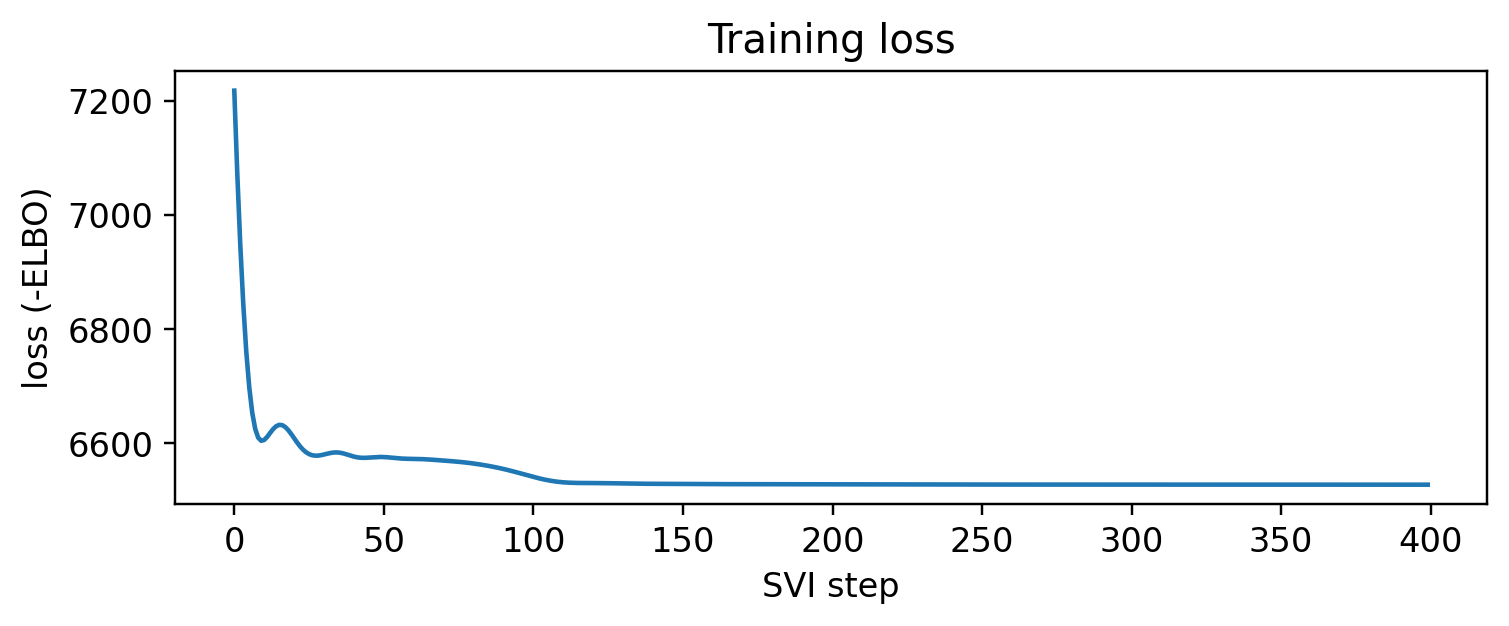

In [4]:
est, losses, guide = learn(sequences, K, M, steps=400, lr=0.05)

plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel("SVI step"); plt.ylabel("loss (-ELBO)")
plt.title("Training loss"); plt.tight_layout(); plt.show()

## Did we recover the parameters?

One subtlety first: **label switching**. Nothing in the model names one state "Rainy" -- the priors are symmetric, so the learner is free to call our `Rainy` state "state 1" or "state 0". The recovered parameters are correct only *up to a permutation* of the states. Before comparing, we line the learned states up with the true ones by matching their emission rows.

In [5]:
def align_states(est_emit, true_emit):
    K = true_emit.shape[0]
    perm = min(itertools.permutations(range(K)),
               key=lambda p: (est_emit[list(p)] - true_emit).abs().sum().item())
    return list(perm)

p = align_states(est["probs_emit"], B_true)
pi_e = est["probs_init"][p].detach()
A_e  = est["probs_trans"][p][:, p].detach()
B_e  = est["probs_emit"][p].detach()

def compare(true, est, idx, cols, name):
    df = pd.concat({"true": pd.DataFrame(true.numpy(), index=idx, columns=cols),
                    "learned": pd.DataFrame(est.numpy().round(3), index=idx, columns=cols)}, axis=1)
    print(name); display(df)

compare(pi_true.reshape(1, -1), pi_e.reshape(1, -1), ["P"], states, "Initial pi:")
compare(A_true, A_e, states, states, "\nTransition A (rows=today, cols=tomorrow):")
compare(B_true, B_e, states, obs_names, "\nEmission B (rows=weather, cols=activity):")

print("\nmax abs error  pi: %.3f   A: %.3f   B: %.3f" % (
    (pi_e - pi_true).abs().max(), (A_e - A_true).abs().max(), (B_e - B_true).abs().max()))

Initial pi:


true       learned       
  Rainy Sunny   Rainy  Sunny
P   0.6   0.4   0.718  0.282


Transition A (rows=today, cols=tomorrow):


true       learned       
      Rainy Sunny   Rainy  Sunny
Rainy   0.7   0.3   0.687  0.313
Sunny   0.4   0.6   0.331  0.669


Emission B (rows=weather, cols=activity):


true            learned              
      walk shop clean    walk   shop  clean
Rainy  0.1  0.4   0.5   0.064  0.412  0.524
Sunny  0.6  0.3   0.1   0.576  0.311  0.113


max abs error  pi: 0.118   A: 0.069   B: 0.036


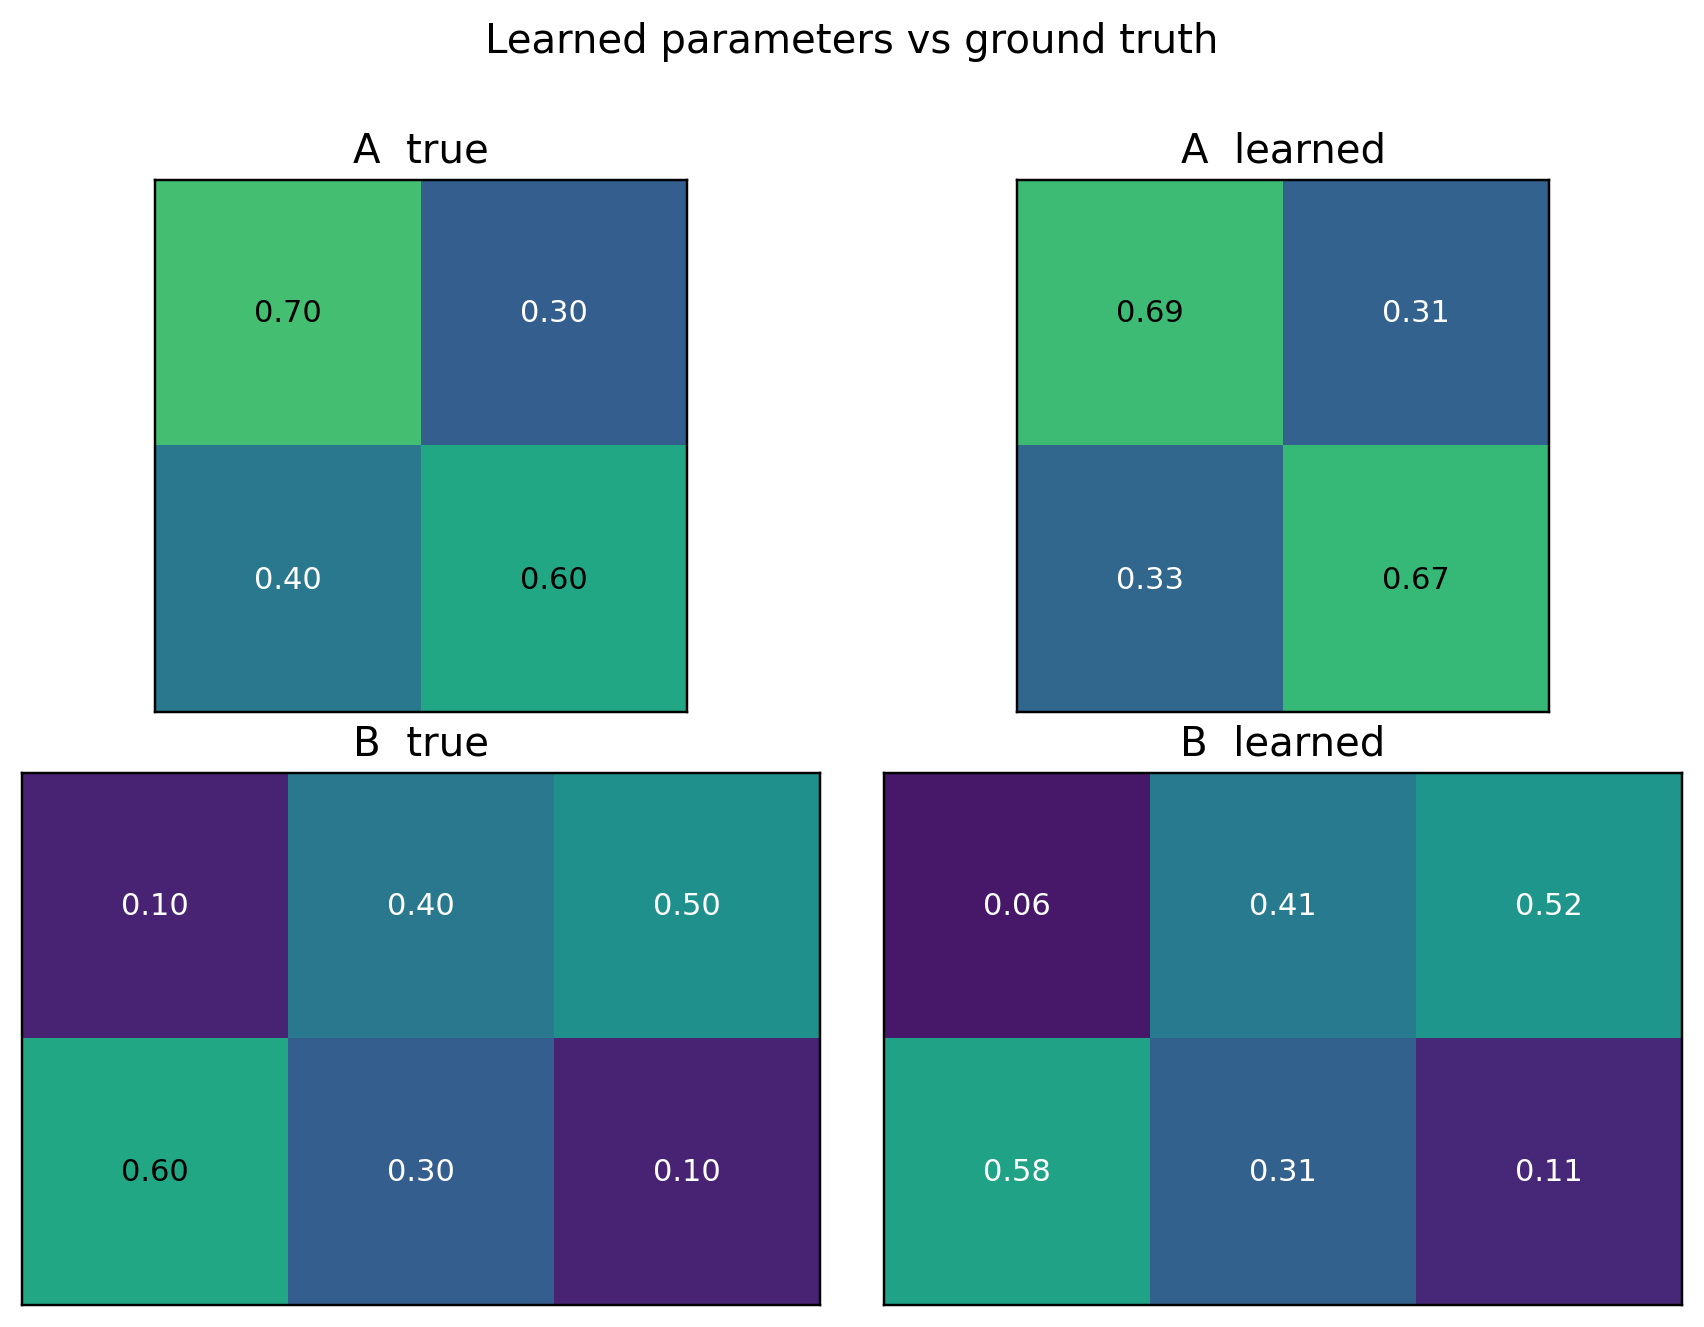

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for ax, mat, title in [(axes[0,0], A_true, "A  true"), (axes[0,1], A_e, "A  learned"),
                       (axes[1,0], B_true, "B  true"), (axes[1,1], B_e, "B  learned")]:
    im = ax.imshow(mat.numpy(), vmin=0, vmax=1, cmap="viridis")
    for (i, j), v in np.ndenumerate(mat.numpy()):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="w" if v < 0.6 else "k", fontsize=10)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Learned parameters vs ground truth", y=1.0)
plt.tight_layout(); plt.show()

## More data, better estimates

A maximum-likelihood estimator is *consistent*: with more data it should approach the truth. Two things make a single run a noisy witness to that -- the error from one dataset is itself a random draw, and gradient EM can settle into a local optimum. So we (i) keep the best of a few random restarts, and (ii) average the recovery error over several independently generated datasets at each size. The averaged transition/emission error then falls cleanly as the data grows. ($\pi$ is left out of this plot -- it is estimated from only as many points as there are sequences, so it stays noisy regardless.)

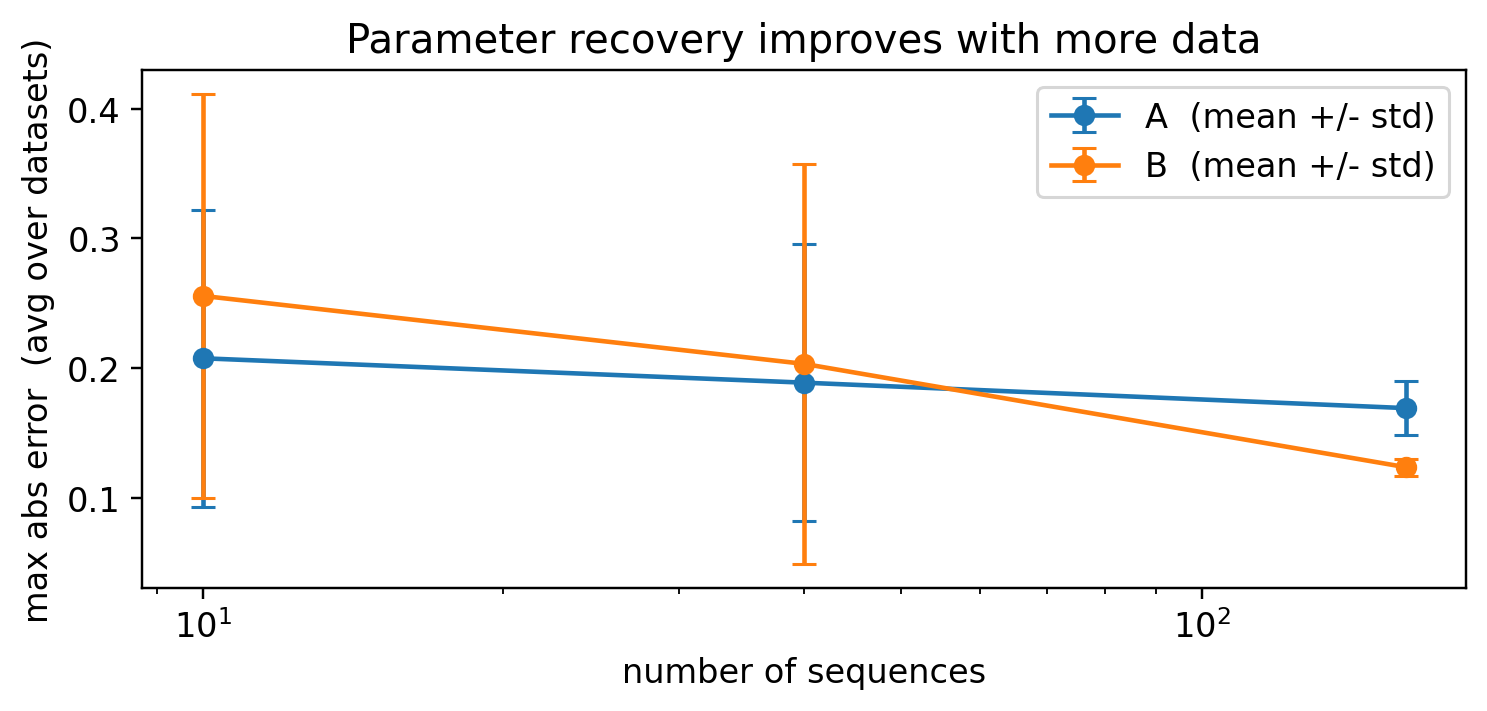

In [7]:
sizes = [10, 40, 160]
n_datasets = 5
errs = {"A": np.zeros((len(sizes), n_datasets)), "B": np.zeros((len(sizes), n_datasets))}
for i, n in enumerate(sizes):
    for d in range(n_datasets):
        data = generate(num_seqs=n, T=60, seed=100 + d)
        e = learn_best(data, K, M, steps=180, restarts=2)
        p = align_states(e["probs_emit"], B_true)
        errs["A"][i, d] = (e["probs_trans"][p][:, p].detach() - A_true).abs().max()
        errs["B"][i, d] = (e["probs_emit"][p].detach() - B_true).abs().max()

plt.figure(figsize=(7, 3.4))
for k in ("A", "B"):
    m, s = errs[k].mean(1), errs[k].std(1)
    plt.errorbar(sizes, m, yerr=s, marker="o", capsize=4, label=f"{k}  (mean +/- std)")
plt.xscale("log"); plt.xlabel("number of sequences")
plt.ylabel("max abs error  (avg over datasets)")
plt.title("Parameter recovery improves with more data")
plt.legend(); plt.tight_layout(); plt.show()

## Sanity check: decode with the learned parameters

A final end-to-end test. We generate a fresh sequence (keeping its hidden weather aside), then run Viterbi decoding -- once with the *true* parameters, once with the *learned* ones -- and see that the learned model recovers almost the same hidden weather.

In [8]:
from pyro.infer import infer_discrete

def gen_with_states(T, seed):
    g = torch.Generator().manual_seed(seed)
    zs, xs = [], []
    z = torch.multinomial(pi_true, 1, generator=g).item()
    for t in range(T):
        if t > 0: z = torch.multinomial(A_true[z], 1, generator=g).item()
        zs.append(z); xs.append(torch.multinomial(B_true[z], 1, generator=g).item())
    return zs, torch.tensor(xs)

def decode(pi, A, B, obs):
    def m(obs):
        z = None
        for t in pyro.markov(range(obs.shape[0])):
            probs = pi if t == 0 else Vindex(A)[..., z, :]
            z = pyro.sample(f"z_{t}", dist.Categorical(probs), infer={"enumerate": "parallel"})
            pyro.sample(f"x_{t}", dist.Categorical(Vindex(B)[..., z, :]), obs=obs[t])
    d = infer_discrete(config_enumerate(m, "parallel"), first_available_dim=-1, temperature=0)
    tr = poutine.trace(d).get_trace(obs)
    return [int(tr.nodes[f"z_{t}"]["value"]) for t in range(obs.shape[0])]

true_z, test_obs = gen_with_states(T=200, seed=123)
dec_true    = decode(pi_true, A_true, B_true, test_obs)
dec_learned = decode(pi_e,    A_e,    B_e,    test_obs)
acc_true    = np.mean(np.array(true_z) == np.array(dec_true))
acc_learned = np.mean(np.array(true_z) == np.array(dec_learned))
print(f"decoding accuracy with TRUE    params: {acc_true:.1%}")
print(f"decoding accuracy with LEARNED params: {acc_learned:.1%}")
print(f"agreement between the two decodings  : {np.mean(np.array(dec_true)==np.array(dec_learned)):.1%}")

decoding accuracy with TRUE    params: 76.0%
decoding accuracy with LEARNED params: 72.0%
agreement between the two decodings  : 95.0%


## Wrap-up

With one `model` function and Pyro's SVI, we recovered $\pi, A, B$ from observations alone -- no forward-backward or Baum-Welch code written by hand, just priors + enumeration + gradient descent. We also met **label switching**, the harmless permutation ambiguity that shows up whenever you learn latent-state models.

Next in the series:

- **continuous emissions** -- replace the categorical activity with a real-valued (Gaussian) observation, the setting that matters for sensors and power meters;
- then the **factorial HMM for energy disaggregation (NILM)**, where several appliances sum into one meter reading -- written without any Kronecker / product-state machinery, and decoded in time *linear* in the number of appliances.